In [35]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from itertools import combinations
from math import factorial

def make_sigma(p, rho):
    Sigma = np.zeros((p, p))
    for j in range(p):
        for k in range(p):
            Sigma[j, k] = rho ** abs(j - k)
    return Sigma

def f1(x):
    return 2.0 * np.log(np.abs(x))

def f2(x):
    return 1.5 * np.sqrt(np.abs(x))

def f3(x):
    return -2.0 * np.log(np.abs(x))

def true_gam_function(X):
    """
    GAM-style true regression function.
    Uses X1, X2, X3 only.
    """
    return (
        1.5
        + f1(X[:, 0])
        + f2(X[:, 1])
        + f3(X[:, 2])
    )

# settings
n = 500
n_reps = 100
p = 5
rho = 0.0
sigma_eps = 1.0

mu = np.zeros(p)
Sigma = make_sigma(p, rho)
feature_names = [f"X{j+1}" for j in range(p)]

# main loop
y_reps = np.zeros((n_reps, n))
X_store = np.zeros((n_reps, n, p))

rng = np.random.default_rng(123)
X = rng.multivariate_normal(mean=mu, cov=Sigma, size=n)
X_df = pd.DataFrame(X, columns=feature_names)

f_true = true_gam_function(X)

y_reps = np.zeros((n_reps, n))

shap_store = np.zeros((n_reps, n, p))
base_store = np.zeros((n_reps, n))

for rep in range(n_reps):
    rng_rep = np.random.default_rng(1000 + rep)

    #X = rng_rep.multivariate_normal(mean=mu, cov=Sigma, size=n)
    #f_true = true_gam_function(X)
    eps = rng_rep.normal(0.0, sigma_eps, size=n)
    y = f_true + eps

    X_store[rep, :, :] = X
    y_reps[rep, :] = y
    
    model = LinearRegression()
    model.fit(X_df, y)

    explainer = shap.Explainer(model, X_df)
    shap_values = explainer(X_df)

    shap_store[rep, :, :] = shap_values.values
    
    base_vals = np.atleast_1d(shap_values.base_values)
    if len(base_vals) == 1:
        base_store[rep, :] = base_vals[0]
    else:
        base_store[rep, :] = base_vals

# average SHAP over replications
avg_shap = shap_store.mean(axis=0)
sd_shap = shap_store.std(axis=0, ddof=1)
avg_base = base_store.mean(axis=0)   # shape (500,)

# one example dataset
X_df = pd.DataFrame(X_store[0], columns=feature_names)
y = y_reps[0]

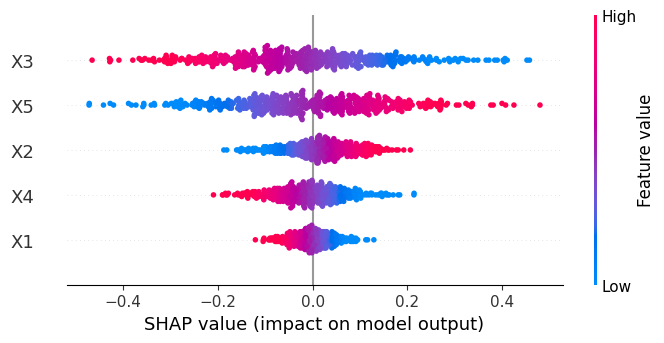

In [36]:
# build SHAP explanation object
avg_explanation = shap.Explanation(
    values=avg_shap,
    base_values=avg_base,
    data=X_df.values,
    feature_names=feature_names
)

# =========================================================
# 6. Beeswarm plot
# =========================================================

#plt.figure(figsize=(8, 5))
#shap.plots.beeswarm(avg_explanation, max_display=p)
#plt.tight_layout()
#plt.savefig("beeswarm_plot_linear1.png", dpi=600, bbox_inches="tight")
#plt.show()
#shap.plots.beeswarm(avg_explanation, max_display=p)
#plt.savefig("beeswarm_plot_linear1.pdf", bbox_inches="tight")
shap.plots.beeswarm(avg_explanation, max_display=p, show=False)
fig = plt.gcf()
fig.savefig("beeswarm_plot_gam1.pdf", bbox_inches="tight")
plt.show()

In [14]:
pip install interpret

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 3.5 MB/s  0:00:01m0:00:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 3.2 MB/s  0:00:01 eta 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached greenlet-3.4.0-cp311-cp311-macosx_11_0_universal2.whl.metadata (3.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.6/15.6 MB 3.4 MB/s  0:00:04m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 3.5 MB/s  0:00:02m0:00:0100:01
Using cached greenlet-3.4.0-cp311-cp311-macosx_11_0_universal2.whl (285 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 3.5 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 3.9 MB/s  0:00:00
  Created wheel for dash-cytoscape: filename=dash_cytosc

In [40]:
import interpret.glassbox
X100 = shap.utils.sample(X, 500)  # 500 instances for use as the background distribution
n_reps = 100
for rep in range(n_reps):
    rng_rep = np.random.default_rng(1000 + rep)

    #X = rng_rep.multivariate_normal(mean=mu, cov=Sigma, size=n)
    #f_true = true_gam_function(X)
    eps = rng_rep.normal(0.0, sigma_eps, size=n)
    y = f_true + eps

    X_store[rep, :, :] = X
    y_reps[rep, :] = y
    
    model = interpret.glassbox.ExplainableBoostingRegressor(interactions=0)
    model.fit(X, y)

    explainer = shap.Explainer(model.predict, X_df)
    shap_values = explainer(X_df)

    shap_store[rep, :, :] = shap_values.values
    
    base_vals = np.atleast_1d(shap_values.base_values)
    if len(base_vals) == 1:
        base_store[rep, :] = base_vals[0]
    else:
        base_store[rep, :] = base_vals

# average SHAP over replications
avg_shap = shap_store.mean(axis=0)
sd_shap = shap_store.std(axis=0, ddof=1)
avg_base = base_store.mean(axis=0)   # shape (500,)

# one example dataset
X_df = pd.DataFrame(X_store[0], columns=feature_names)
y = y_reps[0]

/Users/jingruimu/MATH782-ModelSelection/shap-project/.venv/lib/python3.11/site-packages/interpret/utils/_clean_x.py:3334: UserWarning: Pandas dataframe X does not contain all feature names. Falling back to positional columns.
  warn(


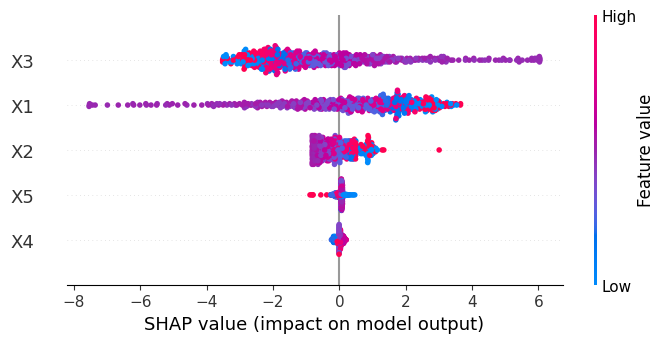

In [41]:
# build SHAP explanation object
avg_explanation = shap.Explanation(
    values=avg_shap,
    base_values=avg_base,
    data=X_df.values,
    feature_names=feature_names
)

# =========================================================
# 6. Beeswarm plot
# =========================================================

#plt.figure(figsize=(8, 5))
#shap.plots.beeswarm(avg_explanation, max_display=p)
#plt.tight_layout()
#plt.savefig("beeswarm_plot_linear1.png", dpi=600, bbox_inches="tight")
#plt.show()
#shap.plots.beeswarm(avg_explanation, max_display=p)
#plt.savefig("beeswarm_plot_linear1.pdf", bbox_inches="tight")
shap.plots.beeswarm(avg_explanation, max_display=p, show=False)
fig = plt.gcf()
fig.savefig("beeswarm_plot_gam_booster1.pdf", bbox_inches="tight")
plt.show()